# The Orthogonal Engine Mount System

### A worked walkthrough of Furusawa et al., SAE 830228 (Yamaha, 1983)

---

**What the paper is actually about, in one paragraph.**

A motorcycle engine mounting has to do two contradictory things. It must be
*soft*, so that the engine's own shaking does not reach the rider. And it must
be *stiff*, because the engine is a structural member of the chassis — soften it
and you get weave, chain snatch, and a frame that flexes. Every conventional
answer to this is a compromise along a single axis: softer mounts, better
isolation, worse handling.

The paper's idea is to stop treating it as one axis. A rigid body on mounts has
six modes. A given excitation does not necessarily excite all six — it excites a
mode only in proportion to the *projection of the force vector onto that mode
shape*. So if you can arrange the geometry such that the engine's dominant
excitation is **orthogonal to five of the six mode shapes**, then only one mode
can respond. You then make that one mode soft (put it below the usable rev
range) and make the other five as stiff as the chassis wants. You are no longer
trading isolation against stiffness; you are isolating in one direction and
being stiff in the other five.

That is the whole idea. Everything else in the paper is the algebra of *when*
that orthogonality can be arranged, and what it costs you.

---

**How to read this notebook.** Sections S1–S7 build the theory from the ground
up, with every equation checked numerically against the paper's own closed
forms. S8 applies it to a reconstruction of the paper's own machine. S9 asks how
fragile the trick is. S10 is the template for your own engine.

Sections marked ⟨beyond the paper⟩ go further than SAE 830228 — real crank
excitation, arbitrary mount layouts, damping.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import EngFormatter

import orthomount as om
import params_rz250 as P

D  = np.deg2rad
Dg = np.rad2deg

# --- plot style: one system, used everywhere in this notebook --------------
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
          "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, INK2, GRID = "#0b0b0b", "#52514e", "#d8d7d2"
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 10.5, "axes.titleweight": "semibold",
    "axes.labelsize": 9, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.6, "grid.alpha": 0.9,
    "xtick.color": INK2, "ytick.color": INK2,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "legend.frameon": False, "legend.fontsize": 8.5,
    "lines.linewidth": 2.0, "font.size": 9,
    "axes.prop_cycle": plt.cycler(color=SERIES),
    "axes.spines.top": False, "axes.spines.right": False,
})

def tidy(ax, title=None, xlabel=None, ylabel=None):
    if title:  ax.set_title(title, loc="left", pad=10)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    return ax

np.set_printoptions(precision=4, suppress=True, linewidth=110)
print("orthomount loaded.")

orthomount loaded.


---
## S1 · The conflict the paper is trying to escape

Before the clever part, it's worth seeing the wall they hit.

Take the simplest possible picture: a mass on a spring, excited by a force that
grows with $\omega^2$ (which is what an inertia force does). The fraction of
that force reaching the chassis is the transmissibility

$$T(\omega)=\left|\frac{1+i\eta}{1-(\omega/\omega_n)^2+i\eta}\right|$$

Isolation ($T<1$) only starts above $\sqrt{2}\,\omega_n$. So to isolate an
engine from, say, 30 Hz upward you need $\omega_n \lesssim 21$ Hz — a mount so
soft that the engine flops around in the frame.

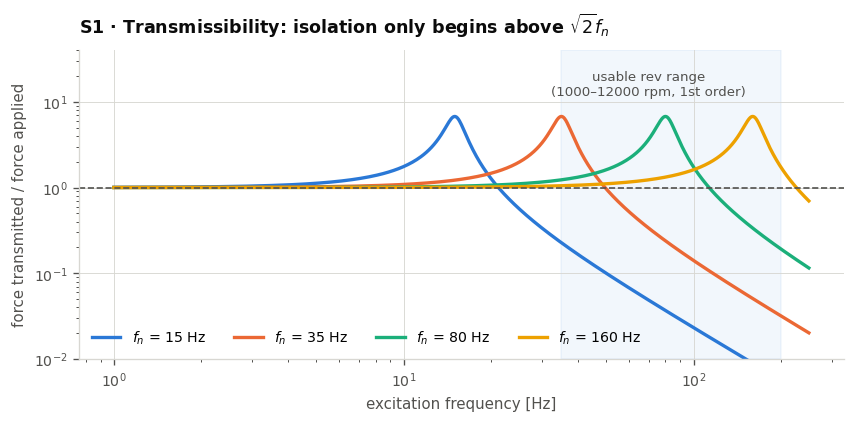

To isolate from 35 Hz upward you need f_n below 24.7 Hz in EVERY direction — which is why conventional
rubber mounting costs you chassis stiffness.


In [2]:
f  = np.linspace(1, 250, 2000)
eta = 0.15
fig, ax = plt.subplots(figsize=(7.2, 3.6))
for i, fn in enumerate([15, 35, 80, 160]):
    r = f / fn
    T = np.abs((1 + 1j*eta) / (1 - r**2 + 1j*eta))
    ax.loglog(f, T, color=SERIES[i], label=f"$f_n$ = {fn} Hz")
ax.axhline(1.0, color=INK2, lw=1.0, ls="--")
ax.axvspan(35, 200, color=SERIES[0], alpha=0.06)
ax.text(70, 12, "usable rev range\n(1000–12000 rpm, 1st order)",
        color=INK2, fontsize=8, ha="center")
ax.set_ylim(1e-2, 40)
tidy(ax, "S1 · Transmissibility: isolation only begins above $\\sqrt{2}f_n$",
     "excitation frequency [Hz]", "force transmitted / force applied")
ax.legend(ncol=4, loc="lower left")
plt.tight_layout(); plt.show()

print("To isolate from 35 Hz upward you need f_n below "
      f"{35/np.sqrt(2):.1f} Hz in EVERY direction — which is why conventional")
print("rubber mounting costs you chassis stiffness.")

The paper's escape: you do **not** need $f_n$ low in every direction. You need it
low only in the *one* direction the engine actually pushes — provided you can
guarantee the other five directions never get excited at all.

That guarantee is what "orthogonal" means in the title.

---
## S2 · The equations of motion, and why modes are the right language

**Paper Eqs. (1)–(6).** The engine is a rigid body with six degrees of freedom

$$q = [x,\ y,\ z,\ \phi,\ \theta,\ \psi]^\mathsf{T}$$

($x$ fore/aft, $y$ lateral, $z$ vertical; $\phi$ roll about $x$, $\theta$ pitch
about $y$, $\psi$ yaw about $z$), so

$$[M]\{\ddot q\} + [K]\{q\} = \{f\} \tag{1}$$

Assume harmonic motion $q = Qe^{i\omega t}$, $f = Fe^{i\omega t}$:

$$\left(-\omega^2[M]+[K]\right)\{Q\} = \{F\} \tag{2}$$

Setting $F=0$ gives the eigenproblem, Eq. (3), whose solutions $\omega_r$ and
$\{u^r\}$ satisfy the **orthogonality conditions**, Eqs. (4)–(5):

$$\{u^s\}^\mathsf{T}[M]\{u^r\} = \begin{cases}0 & s\neq r\\ m_r & s=r\end{cases}
\qquad
\{u^s\}^\mathsf{T}[K]\{u^r\} = \begin{cases}0 & s\neq r\\ k_r & s=r\end{cases}$$

and the forced response separates into a sum over modes — **Eq. (6)**:

$$\{Q\} = \sum_{r=1}^{n}\frac{\{u^r\}\{u^r\}^\mathsf{T}\{F\}}
{m_r\left(\omega_r^2-\omega^2\right)} \tag{6}$$

Stare at the numerator. Mode $r$ contributes to the response with weight
$\{u^r\}^\mathsf{T}\{F\}$ — the **modal participation factor**. If that inner
product is zero, mode $r$ contributes *nothing*, at any frequency, even exactly
at its own resonance.

**That single observation is the entire paper.** Everything from Eq. (7) onward
is working out how to make five of those six inner products vanish.

In [3]:
# Verify Eq (6) numerically: modal superposition == direct matrix inversion.
sys_demo = P.system()
f_exc = np.array([0, 0, 0, 1.0, 0, 0.0])          # unit moment about x
w = 2*np.pi*np.linspace(5, 250, 600)

Q_direct = sys_demo.response(w, f_exc, damped=False).real
Q_modal  = sys_demo.modal_response(w, f_exc).sum(axis=2).real

err = np.max(np.abs(Q_direct - Q_modal)) / np.max(np.abs(Q_direct))
print(f"max relative difference between Eq.(6) and inv(-w^2 M + K): {err:.2e}")
assert err < 1e-9

max relative difference between Eq.(6) and inv(-w^2 M + K): 2.06e-13


In [4]:
res = sys_demo.modal()
print("Natural frequencies of the demo engine mounting:\n")
for i, (fh, lab, mm) in enumerate(zip(res.f_hz, res.labels, res.modal_mass)):
    print(f"  mode {i+1}:  {fh:7.2f} Hz   {lab:<14s}  modal mass/inertia {mm:.4g}")

print("\nMode shape matrix (columns are modes, rows are DOF):")
print("        " + "".join(f"{i+1:>10d}" for i in range(6)))
for j, lab in enumerate(om.DOF_LABELS):
    print(f"{lab:>14s}" + "".join(f"{v:10.3f}" for v in res.modes[j]))

Natural frequencies of the demo engine mounting:

  mode 1:    34.48 Hz   phi (roll)      modal mass/inertia 1.185
  mode 2:    47.01 Hz   y (lateral)     modal mass/inertia 24.86
  mode 3:    73.76 Hz   psi (yaw)       modal mass/inertia 2.059
  mode 4:   106.81 Hz   z (bounce)      modal mass/inertia 60.46
  mode 5:   106.82 Hz   x (fore/aft)    modal mass/inertia 60.45
  mode 6:   162.60 Hz   theta (pitch)   modal mass/inertia 1.3

Mode shape matrix (columns are modes, rows are DOF):
                 1         2         3         4         5         6
  x (fore/aft)    -0.000    -0.000     0.000     0.715     1.000     0.001
   y (lateral)    -0.000    -0.758     0.063     0.000    -0.000    -0.000
    z (bounce)     0.000     0.000    -0.000     1.000    -0.715     0.002
    phi (roll)     1.000     0.440     0.441     0.000    -0.000     0.000
 theta (pitch)    -0.000    -0.000    -0.000    -0.096    -0.000     1.000
     psi (yaw)    -0.494     1.000     1.000     0.000    -0.000

---
## S3 · What the paper's assumptions buy you

**Paper, p. 2.** Six assumptions, and each one is load-bearing:

1. the engine is a rigid body
2. displacements and rotations are small
3. each mount is a massless linear spring
4. the chassis is rigid with infinite mass *(relaxed later in the paper)*
5. **$y$ is a principal axis of inertia, and of elasticity, and the centre of
   elasticity sits on the CG**
6. **the only excitation is the unbalanced primary inertia moment about $x$**

Assumption 5 is the one that does the work. It block-diagonalises the problem:

$$
[M]=\begin{bmatrix}
m&&&&&\\ &m&&&&\\ &&m&&&\\
&&&I_x&&-I_{zx}\\ &&&&I_y&\\ &&&-I_{zx}&&I_z
\end{bmatrix}
\qquad
[K]=\begin{bmatrix}
K_{xx}&&K_{xz}&&&\\ &K_{yy}&&&&\\ K_{xz}&&K_{zz}&&&\\
&&&K_{\phi\phi}&&K_{\phi\psi}\\ &&&&K_{\theta\theta}&\\
&&&K_{\phi\psi}&&K_{\psi\psi}
\end{bmatrix}
$$

Read off what is coupled to what:

| block | DOF | coupled by |
|---|---|---|
| translation in the symmetry plane | $x,z$ | $K_{xz}$ |
| lateral | $y$ | nothing |
| pitch | $\theta$ | nothing |
| **roll–yaw** | $\phi,\psi$ | $I_{zx}$ **and** $K_{\phi\psi}$ |

The excitation is a pure moment about $x$, so it touches only $\phi$. And $\phi$
talks only to $\psi$. **The 6-DOF problem has collapsed to a 2-DOF problem** —
the roll–yaw pair — and everything the paper does happens inside that $2\times2$.

Two modes live in there. The paper is going to kill one of them.

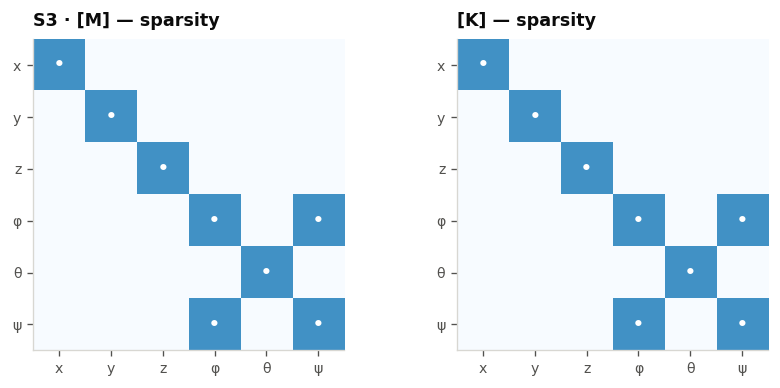

The (φ,ψ) 2x2 sub-blocks that carry all the physics:

  M_r =
 [[1.1125 0.2815]
 [0.2815 1.4375]]

  K_r =
 [[52140.6198  4873.787 ]
 [ 4873.787  25359.3802]]


In [5]:
# Build the paper's idealised matrices and look at the structure.
M, K = om.paper_system(
    mass=P.MASS, I_xi=P.I_XI, I_eta=P.I_ETA, I_zeta=P.I_ZETA, alpha=P.ALPHA,
    K_xi=5.3e4, K_eta=4.0e4, K_zeta=2.45e4, beta=D(-10.0),
    K_trans=(1.8e7, 3.5e6, 1.7e7))

def spy(ax, A, title):
    Z = np.abs(A) / np.abs(A).max()
    ax.imshow(Z > 1e-12, cmap="Blues", vmin=0, vmax=1.6)
    ax.set_xticks(range(6)); ax.set_yticks(range(6))
    lab = ["x","y","z","φ","θ","ψ"]
    ax.set_xticklabels(lab); ax.set_yticklabels(lab)
    ax.grid(False); ax.set_title(title, loc="left", pad=8)
    for i in range(6):
        for j in range(6):
            if abs(A[i, j]) > 1e-12:
                ax.text(j, i, "•", ha="center", va="center", color="white", fontsize=13)

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.3))
spy(axes[0], M, "S3 · [M] — sparsity")
spy(axes[1], K, "[K] — sparsity")
plt.tight_layout(); plt.show()

print("The (φ,ψ) 2x2 sub-blocks that carry all the physics:")
print("\n  M_r =\n", M[np.ix_([3,5],[3,5])])
print("\n  K_r =\n", K[np.ix_([3,5],[3,5])])

---
## S4 · The orthogonality condition — the heart of the paper

**Paper Eqs. (10)–(16).**

Inside the roll–yaw pair, write the two mode shapes as
$\{u^1\}=[u^1_\phi,\ u^1_\psi]^\mathsf{T}$ and
$\{u^2\}=[u^2_\phi,\ u^2_\psi]^\mathsf{T}$.

The excitation is $\{F\}=[F_\phi,\ 0]^\mathsf{T}$. Its participation in mode 2 is

$$\{u^2\}^\mathsf{T}\{F\} = u^2_\phi F_\phi$$

So mode 2 goes silent **iff $u^2_\phi = 0$**, i.e. iff

$$\{u^2\} = [0,\ 1]^\mathsf{T} \tag{11}$$

*Mode 2 must be pure yaw.* Then Eq. (6) collapses to a single term, Eq. (12):
the engine has exactly one resonance, and its motion is always the same shape
regardless of frequency.

**When is that possible?** Apply the orthogonality conditions (4) and (5) with
$s=1$, $r=2$ and substitute Eq. (11) — the paper's Eqs. (13)–(14):

$$-I_{zx}u^1_\phi + I_z u^1_\psi = 0 \qquad\text{(mass orthogonality)}$$
$$\ \ K_{\phi\psi}u^1_\phi + K_{\psi\psi}u^1_\psi = 0 \qquad\text{(stiffness orthogonality)}$$

Both are conditions on the *same* ratio $u^1_\psi/u^1_\phi$. A non-trivial
solution needs the determinant to vanish, Eq. (15):

$$I_z K_{\phi\psi} + I_{zx} K_{\psi\psi}=0$$

which is the paper's central result, **Eq. (16)**:

$$\boxed{\ R \;=\; \frac{I_{zx}}{I_z} \;=\; -\frac{K_{\phi\psi}}{K_{\psi\psi}}\ }$$

In words: **the inertial coupling of the engine and the elastic coupling of its
mounts must match.** Not be small — *match*. The paper's phrase for this is that
"the static coupling due to the stiffness of the engine support is positively
utilized against the dynamic coupling."

This is genuinely counter-intuitive. Textbook mount design tries to *decouple*
the modes ($I_{zx}\to0$, $K_{\phi\psi}\to0$). Furusawa deliberately introduces
elastic cross-coupling, sized to cancel the inertial cross-coupling in the
one specific sense that makes mode 2 invisible to the excitation.

engine gives   p = I_xi/I_zeta = 0.5937,  alpha = 30.0 deg
           ->  R = -0.19580
mounts have    q = K_xi/K_zeta = 2.1633
           ->  required beta = -10.21 deg  (or -68.71 deg)

The paper's machine used alpha = 30 deg and an elastic axis inclined 10 deg
the other way.  Here q was CHOSEN so that beta lands there -- that is how the
reconstruction in params_rz250.py was pinned down, not an independent check.


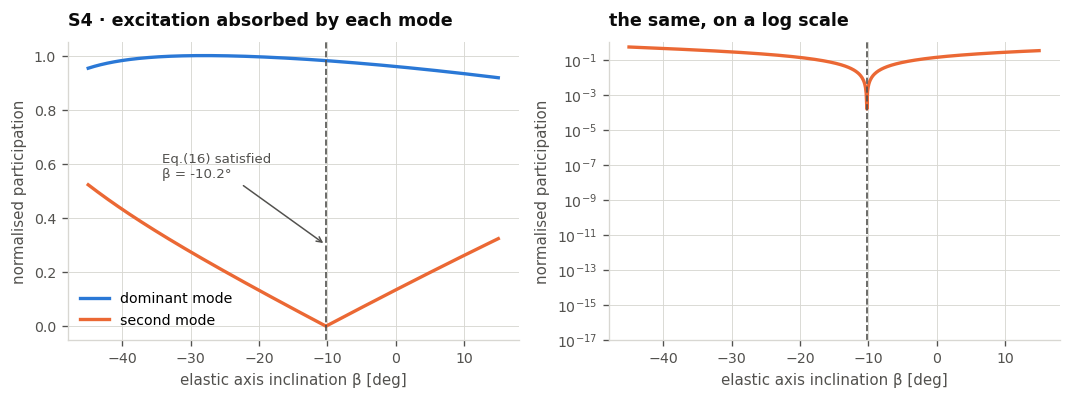

In [6]:
# Demonstrate the condition directly. Sweep beta, watch mode 2's participation.
I_xi, I_eta, I_zeta, alpha = P.I_XI, P.I_ETA, P.I_ZETA, P.ALPHA
K_xi, K_eta, K_zeta = 5.30e4, 4.0e4, 2.45e4
p, q = I_xi/I_zeta, K_xi/K_zeta

R_req = om.R_from_inertia(p, alpha)
beta_ok, beta_alt = om.solve_beta_for_R(R_req, q)
print(f"engine gives   p = I_xi/I_zeta = {p:.4f},  alpha = {Dg(alpha):.1f} deg")
print(f"           ->  R = {R_req:+.5f}")
print(f"mounts have    q = K_xi/K_zeta = {q:.4f}")
print(f"           ->  required beta = {Dg(beta_ok):+.2f} deg  (or {Dg(beta_alt):+.2f} deg)")
print("\nThe paper's machine used alpha = 30 deg and an elastic axis inclined 10 deg")
print("the other way.  Here q was CHOSEN so that beta lands there -- that is how the")
print("reconstruction in params_rz250.py was pinned down, not an independent check.")

betas = D(np.linspace(-45, 15, 601))
part = np.zeros((betas.size, 2))
freqs = np.zeros((betas.size, 2))
f_roll = np.array([0, 0, 0, 1.0, 0, 0])
for i, b in enumerate(betas):
    Mi, Ki = om.paper_system(P.MASS, I_xi, I_eta, I_zeta, alpha,
                             K_xi, K_eta, K_zeta, b, K_trans=(1.8e7, 3.5e6, 1.7e7))
    r = om.modal_from_matrices(Mi, Ki)
    pp = r.normalised_participation(f_roll)
    k = np.argsort(pp)[::-1][:2]
    part[i]  = pp[k]
    freqs[i] = r.f_hz[k]

fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.4))
axes[0].plot(Dg(betas), part[:, 0], color=SERIES[0], label="dominant mode")
axes[0].plot(Dg(betas), part[:, 1], color=SERIES[1], label="second mode")
axes[0].axvline(Dg(beta_ok), color=INK2, ls="--", lw=1.0)
axes[0].annotate(f"Eq.(16) satisfied\nβ = {Dg(beta_ok):.1f}°",
                 xy=(Dg(beta_ok), 0.30), xytext=(Dg(beta_ok)-24, 0.55),
                 color=INK2, fontsize=8,
                 arrowprops=dict(arrowstyle="->", color=INK2, lw=0.9))
tidy(axes[0], "S4 · excitation absorbed by each mode",
     "elastic axis inclination β [deg]", "normalised participation")
axes[0].legend()

axes[1].semilogy(Dg(betas), part[:, 1], color=SERIES[1])
axes[1].axvline(Dg(beta_ok), color=INK2, ls="--", lw=1.0)
tidy(axes[1], "the same, on a log scale",
     "elastic axis inclination β [deg]", "normalised participation")
axes[1].set_ylim(1e-17, 1)
plt.tight_layout(); plt.show()

The right-hand panel is the point: at the design $\beta$ the second mode's
participation is not *small*, it is zero to machine precision. It is a genuine
orthogonality, not a cancellation that happens to be lucky at one frequency.

Notice also that the condition says nothing about the *magnitude* of the
stiffnesses — only their ratio $q$ and their orientation $\beta$. You can make
the whole mounting arbitrarily stiff and still keep the orthogonality. That is
exactly the freedom the paper is buying.

---
## S5 · The geometry: $\alpha$, $\beta$, $p$, $q$

**Paper Eqs. (20)–(22).** So far $R$ has been expressed through matrix entries.
Now express it through things you can actually measure and draw.

Let the engine's principal axes of inertia in the $x$–$z$ plane be $\xi,\zeta$,
inclined by $\alpha$; and the principal axes of elasticity of the mount set be
inclined by $\beta$. Then Eq. (20):

$$I_x = I_\xi\cos^2\alpha + I_\zeta\sin^2\alpha,\quad
  I_z = I_\xi\sin^2\alpha + I_\zeta\cos^2\alpha,\quad
  I_{zx} = (I_\xi-I_\zeta)\sin\alpha\cos\alpha$$

and Eq. (21) is the same rotation applied to the stiffnesses. With the two
ratios

$$p = \frac{I_\xi}{I_\zeta},\qquad q = \frac{K^\phi_\xi}{K^\psi_\zeta}$$

both expressions for $R$ take **the identical algebraic form** — Eq. (22):

$$\frac{(p-1)\tan\alpha}{p\tan^2\alpha+1} \;=\; R \;=\; \frac{(q-1)\tan\beta}{q\tan^2\beta+1}$$

That symmetry is the reason Fig. 2 of the paper serves double duty: the same
curve, read one way, gives you $(q,\beta)$ for a required $R$; read the other
way with $p$ for $q$ and $\alpha$ for $\beta$, it gives you the $R$ your engine
produces.

**The design limit.** Solving Eq. (22) for $\tan\beta$ gives a quadratic, so a
real $\beta$ exists only when

$$|R| \le \frac{|q-1|}{2\sqrt q}$$

If your mounts are too *isotropic* ($q\approx1$) they cannot generate enough
elastic cross-coupling to cancel the engine's inertial cross-coupling, and the
scheme is simply unavailable. This inequality is not in the paper — it falls out
of inverting Eq. (22) — and it is the first thing to check on a new engine.

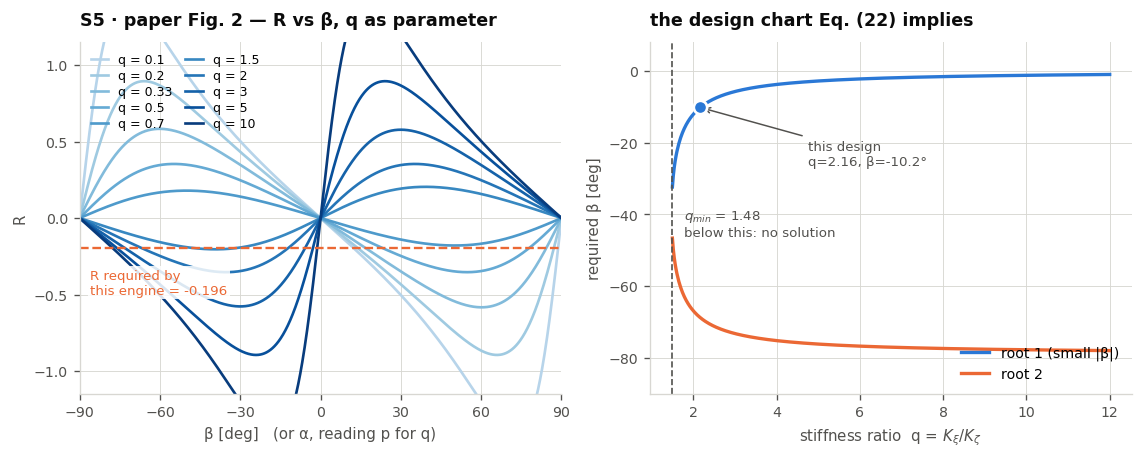

For this engine (R = -0.1958) the mounts must have q >= 1.48
i.e. at least 1.5:1 anisotropy in rotational stiffness before the
orthogonal scheme is geometrically possible at all.


In [7]:
# --- reproduce the paper's Fig. 2, and add the design chart it implies ------
beta_grid = D(np.linspace(-90, 90, 1200))
q_levels  = [0.1, 0.2, 0.33, 0.5, 0.7, 1.5, 2, 3, 5, 10]
# q is a magnitude parameter, not an identity: use one hue, light -> dark.
ramp = plt.cm.Blues(np.linspace(0.30, 0.95, len(q_levels)))

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.9))

ax = axes[0]
for i, qq in enumerate(q_levels):
    ax.plot(Dg(beta_grid), om.R_from_stiffness(qq, beta_grid),
            color=ramp[i], lw=1.6, label=f"q = {qq:g}")
ax.axhline(R_req, color=SERIES[1], ls="--", lw=1.4)
ax.text(-86, R_req - 0.30, f"R required by\nthis engine = {R_req:+.3f}",
        fontsize=8, color=SERIES[1], ha="left",
        bbox=dict(fc="white", ec="none", alpha=0.85, pad=1.5))
ax.set_xlim(-90, 90); ax.set_ylim(-1.15, 1.15)
ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])
tidy(ax, "S5 · paper Fig. 2 — R vs β, q as parameter",
     "β [deg]   (or α, reading p for q)", "R")
ax.legend(ncol=2, fontsize=7.5, loc="upper left", handlelength=1.4,
          columnspacing=1.0, labelspacing=0.25)

# design chart: for a required R, which (q, beta) pairs work?
ax = axes[1]
qs = np.linspace(1.01, 12, 500)
b1 = np.array([om.solve_beta_for_R(R_req, qq)[0] for qq in qs])
b2 = np.array([om.solve_beta_for_R(R_req, qq)[1] for qq in qs])
ax.plot(qs, Dg(b1), color=SERIES[0], label="root 1 (small |β|)")
ax.plot(qs, Dg(b2), color=SERIES[1], label="root 2")
qmin = om.q_min_for_R(R_req)
ax.axvline(qmin, color=INK2, ls="--", lw=1.0)
ax.text(qmin + 0.3, -46, f"$q_{{min}}$ = {qmin:.2f}\nbelow this: no solution",
        fontsize=8, color=INK2)
ax.plot([q], [Dg(beta_ok)], "o", ms=8, color=SERIES[0],
        markeredgecolor="white", markeredgewidth=1.6, zorder=5)
ax.annotate(f"this design\nq={q:.2f}, β={Dg(beta_ok):.1f}°",
            xy=(q, Dg(beta_ok)), xytext=(q + 2.6, Dg(beta_ok) - 16),
            fontsize=8, color=INK2,
            arrowprops=dict(arrowstyle="->", color=INK2, lw=0.9))
ax.set_ylim(-90, 8)
tidy(ax, "the design chart Eq. (22) implies",
     "stiffness ratio  q = $K_ξ/K_ζ$", "required β [deg]")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

print(f"For this engine (R = {R_req:+.4f}) the mounts must have q >= {qmin:.2f}")
print(f"i.e. at least {qmin:.1f}:1 anisotropy in rotational stiffness before the")
print("orthogonal scheme is geometrically possible at all.")

---
## S6 · What you get: the frequency $\omega_1$ and the rocking axis $\delta$

**Paper Eqs. (23)–(32).** Once Eq. (16) holds, three things follow.

**The surviving mode shape**, Eq. (23):
$$[u^1_\phi,\ u^1_\psi]^\mathsf{T} = [1,\ R]^\mathsf{T}$$

**Its modal inertia**, Eqs. (24)–(25):
$$m_1 = \frac{I_xI_z-I_{zx}^2}{I_z} = \frac{I_\xi I_\zeta}{I_z}
      = \frac{I_\xi}{p\sin^2\alpha+\cos^2\alpha}$$

**Its frequency**, Eq. (27):
$$\omega_1^2 = \frac{K^\phi_\xi\,(p\sin^2\alpha+\cos^2\alpha)}
                    {I_\xi\,(q\sin^2\beta+\cos^2\beta)}$$

This is the design knob. $\alpha,p$ come from the engine; $\beta,q$ are pinned
by Eq. (22); so a *single* number, $K^\phi_\xi$, sets where the one resonance
lands. Put it below the usable rev range and you are done.

**The rocking axis**, Eqs. (28)–(29):
$$\tan\delta = -R = \frac{(1-p)\tan\alpha}{p\tan^2\alpha+1}$$

The engine does *not* rock about $x$. It rocks about an axis inclined by
$\delta$ — a fixed axis, the same at every frequency. Two elegant checks tie the
three angles together, Eqs. (31)–(32):

$$\tan(\alpha-\delta) = p\tan\alpha, \qquad \tan(\beta-\delta) = q\tan\beta$$

Because $p<1$ and $q>1$ in a typical design, $\delta$ lands *between* the two
principal axes — the rocking axis is pulled off $x$ toward the inertia axis and
away from the elastic axis. That is the geometric picture of "the static
coupling is used against the dynamic coupling".

In [8]:
delta = om.delta_paper(p, alpha)
m1    = om.modal_mass_paper(I_xi, I_zeta, alpha)
w1    = om.omega1_paper(K_xi, I_xi, p, q, alpha, beta_ok)

print(f"  principal inertia axis   α = {Dg(alpha):+7.2f} deg")
print(f"  principal elastic axis   β = {Dg(beta_ok):+7.2f} deg")
print(f"  axis of rotation         δ = {Dg(delta):+7.2f} deg")
print(f"  modal inertia           m1 = {m1:.4f} kg m^2")
print(f"  resonance               f1 = {w1/2/np.pi:.2f} Hz")
print()
print(f"  check Eq.(31):  tan(α-δ) = {np.tan(alpha-delta):.6f}   p tanα = {p*np.tan(alpha):.6f}")
print(f"  check Eq.(32):  tan(β-δ) = {np.tan(beta_ok-delta):.6f}   q tanβ = {q*np.tan(beta_ok):.6f}")

# what K_xi do we need for a 35 Hz mode?
K_need = om.K_xi_for_target_f1(35.0, I_xi, p, q, alpha, beta_ok)
print(f"\n  for f1 = 35 Hz exactly:  K_xi = {K_need:,.0f} N m/rad")

  principal inertia axis   α =  +30.00 deg
  principal elastic axis   β =  -10.21 deg
  axis of rotation         δ =  +11.08 deg
  modal inertia           m1 = 1.0574 kg m^2
  resonance               f1 = 35.00 Hz

  check Eq.(31):  tan(α-δ) = 0.342802   p tanα = 0.342802
  check Eq.(32):  tan(β-δ) = -0.389672   q tanβ = -0.389672

  for f1 = 35 Hz exactly:  K_xi = 53,006 N m/rad


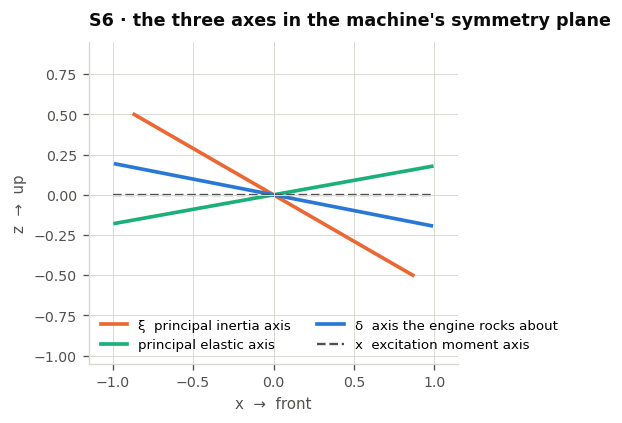

In [9]:
# Draw the three axes.  This picture is the paper's Fig. 1 made quantitative.
fig, ax = plt.subplots(figsize=(6.2, 3.6))
L = 1.0
for ang, col, lab, ls in ((alpha,   SERIES[1], "ξ  principal inertia axis", "-"),
                          (beta_ok, SERIES[2], "principal elastic axis",    "-"),
                          (delta,   SERIES[0], "δ  axis the engine rocks about", "-"),
                          (0.0,     INK2,      "x  excitation moment axis", "--")):
    # paper convention: R_y(+angle) sends +x toward -z
    ax.plot([-L*np.cos(ang), L*np.cos(ang)], [L*np.sin(ang), -L*np.sin(ang)],
            color=col, ls=ls, lw=2.2 if ls == "-" else 1.4, label=lab)
ax.set_aspect("equal"); ax.set_xlim(-1.15, 1.15); ax.set_ylim(-1.05, 0.95)
ax.axhline(0, color=GRID, lw=0.6); ax.axvline(0, color=GRID, lw=0.6)
tidy(ax, "S6 · the three axes in the machine's symmetry plane", "x  →  front", "z  →  up")
ax.legend(loc="lower left", fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

---
## S7 · The design procedure, as a recipe

The paper states it in one dense paragraph at the end of the theory section.
Unpacked:

| step | what you do | equation |
|---|---|---|
| 1 | Measure the engine as a rigid body → $I_\xi, I_\zeta, \alpha$, hence $p$ and $R$ | (20), (22) |
| 2 | Check feasibility: is $q$ achievable, given $\|R\|\le(q-1)/2\sqrt q$? | — |
| 3 | Choose the mount set's stiffness ratio $q$, then solve for the required elastic-axis inclination $\beta$ | (22) |
| 4 | Choose the target resonance $f_1$ (below the usable rev range) → gives $K^\phi_\xi$ | (27) |
| 5 | Read off the rocking axis $\delta$; check nothing collides with it | (29) |
| 6 | Realise $q$, $\beta$, $K^\phi_\xi$ with actual bushes at actual positions | ⟨beyond the paper⟩ |

Step 6 is the one the paper is quiet about, and it is where most of the
engineering effort really goes — you have to hit three targets ($q$, $\beta$,
$K^\phi_\xi$) *and* keep the elastic centre on the CG *and* keep the other five
frequencies high, using mount positions and rubber rates. S8 does exactly that.

In [10]:
def design(I_xi, I_zeta, alpha, q, f1_target):
    '''The paper's design procedure, start to finish.'''
    p = I_xi / I_zeta
    R = om.R_from_inertia(p, alpha)
    q_min = om.q_min_for_R(R)
    if q < q_min:
        raise ValueError(f"q = {q:.2f} is below q_min = {q_min:.2f}: "
                         "the mounts cannot generate enough elastic coupling.")
    beta, beta2 = om.solve_beta_for_R(R, q)
    K_xi = om.K_xi_for_target_f1(f1_target, I_xi, p, q, alpha, beta)
    return dict(p=p, R=R, q_min=q_min, beta=beta, beta_alt=beta2,
                K_xi=K_xi, K_zeta=K_xi/q,
                delta=om.delta_paper(p, alpha),
                m1=om.modal_mass_paper(I_xi, I_zeta, alpha))

d = design(P.I_XI, P.I_ZETA, P.ALPHA, q=2.163, f1_target=35.0)
for k, v in d.items():
    unit = " deg" if k in ("beta", "beta_alt", "delta") else ""
    val = Dg(v) if unit else v
    print(f"  {k:9s} = {val:12.4f}{unit}")

  p         =       0.5937
  R         =      -0.1958
  q_min     =       1.4757
  beta      =     -10.2138 deg
  beta_alt  =     -68.7080 deg
  K_xi      =   53006.5360
  K_zeta    =   24506.0268
  delta     =      11.0782 deg
  m1        =       1.0574


---
## S8 · The paper's own machine ⟨beyond the paper⟩

The example is a water-cooled two-stroke parallel twin, 180° crank, cylinders
inclined 24° forward — an RZ250/RD350LC-class engine. The paper gives us:

* $\alpha \approx 30°$, $\beta \approx 10°$ the other way
* four cylindrical rubber bushes, two front two rear, *"almost symmetrically in
  the lateral direction with narrow distance"*
* the bushes work **in compression** against fore/aft and vertical engine motion
* Table 2: six measured/predicted natural frequencies, 35 Hz to 180 Hz

It does **not** give inertias, mount positions or rates. `params_rz250.py`
reconstructs a set that lands on Table 2. Two parts of the story fall out of
that reconstruction and are worth pausing on.

### S8.1 · Where the excitation direction actually comes from

The paper simply asserts the excitation is "the unbalanced primary inertia
moment around the $x$ axis". For a 180° twin that is a real, derivable quantity,
so let's derive it rather than assume it.

For each cylinder the reciprocating mass produces a force along the cylinder
axis, $F \approx m_r r\omega^2(\cos\theta + \lambda\cos2\theta)$ with
$\lambda=r/l$. With two cylinders at 180°, offset $\pm d/2$ along the crank:

* **primary forces cancel** (opposite phase)
* **primary couple survives**: $|M_1| = m_r r \omega^2 d$, about an axis
  perpendicular to the cylinder axis
* **secondary forces add** (they are at $2\theta$, so 180° apart in crank angle
  is 360° apart in the second harmonic), giving $2m_r r\lambda\omega^2$
* **no secondary couple**

The cylinders lean 24° forward, so the primary couple axis is tilted 24° from
horizontal. *That* is the paper's "$x$ axis": the analysis frame is aligned with
the excitation, not with the chassis.

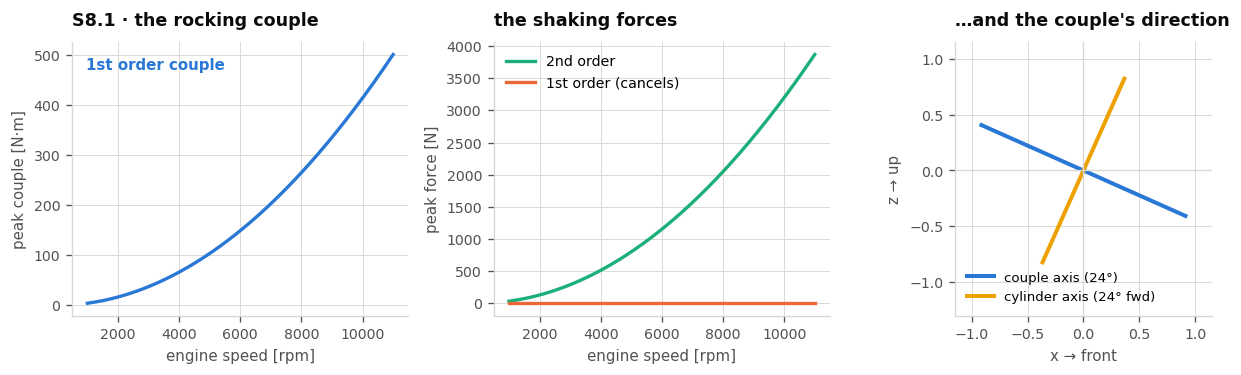

6-component excitation vector, 1st order (normalised):
   [Fx, Fy, Fz, Mx, My, Mz] = [-0.      0.     -0.      0.9135  0.     -0.4067]

primary couple axis is 24.00 deg from horizontal, exactly perpendicular to the 24 deg cylinder axis.


In [11]:
eng = P.engine()
rpm = np.linspace(1000, 11000, 400)
w_e = rpm * 2*np.pi/60

h1_M, h1_F, h2_F = [], [], []
for wi in w_e:
    h = eng.harmonics(wi, n_harm=2)
    h1_F.append(np.linalg.norm(h[1][:3])); h1_M.append(np.linalg.norm(h[1][3:]))
    h2_F.append(np.linalg.norm(h[2][:3]))

fig, axes = plt.subplots(1, 3, figsize=(10.6, 3.2))

ax = axes[0]
ax.plot(rpm, h1_M, color=SERIES[0])
ax.text(0.04, 0.90, "1st order couple", transform=ax.transAxes,
        color=SERIES[0], fontsize=9, fontweight="semibold")
tidy(ax, "S8.1 · the rocking couple", "engine speed [rpm]", "peak couple [N·m]")

ax = axes[1]
ax.plot(rpm, h2_F, color=SERIES[2], label="2nd order")
ax.plot(rpm, h1_F, color=SERIES[1], label="1st order (cancels)")
tidy(ax, "the shaking forces", "engine speed [rpm]", "peak force [N]")
ax.legend(loc="upper left")

# the direction of the primary couple
ax = axes[2]
v = eng.excitation_vector(600.0, order=1)
Mv = v[3:] / np.linalg.norm(v[3:])
tilt = np.arctan2(-Mv[2], Mv[0])
ax.plot([-np.cos(tilt), np.cos(tilt)], [np.sin(tilt), -np.sin(tilt)],
        color=SERIES[0], lw=2.4, label=f"couple axis ({Dg(tilt):.0f}°)")
e = np.array([np.sin(P.CYL_TILT), 0, np.cos(P.CYL_TILT)])
ax.plot([-0.9*e[0], 0.9*e[0]], [-0.9*e[2], 0.9*e[2]],
        color=SERIES[3], lw=2.4, label=f"cylinder axis ({Dg(P.CYL_TILT):.0f}° fwd)")
ax.axhline(0, color=GRID, lw=0.8); ax.axvline(0, color=GRID, lw=0.8)
ax.set_aspect("equal"); ax.set_xlim(-1.15, 1.15); ax.set_ylim(-1.3, 1.15)
tidy(ax, "…and the couple's direction", "x → front", "z → up")
ax.legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.show()

print("6-component excitation vector, 1st order (normalised):")
print("   [Fx, Fy, Fz, Mx, My, Mz] =", v/np.linalg.norm(v))
print(f"\nprimary couple axis is {Dg(tilt):.2f} deg from horizontal, "
      f"exactly perpendicular to the {Dg(P.CYL_TILT):.0f} deg cylinder axis.")

### S8.2 · Why "narrow lateral spacing" is the whole trick, in hardware

Look at what a mount at $(x, y, z)$ contributes to each stiffness:

$$K_{zz}\sim\textstyle\sum k_z,\qquad
K_{\theta\theta}\sim\textstyle\sum k_z x^2,\qquad
K_{\phi\phi}\sim\textstyle\sum \left(k_z y^2 + k_y z^2\right)$$

Roll stiffness is the only one that depends on the **lateral** spacing $y$.
Everything else depends on $x$, $z$, or the raw rates. So pushing the four
bushes close together laterally collapses the roll stiffness while leaving
bounce, fore/aft, pitch and yaw stiffness untouched.

That is how the paper gets a 35 Hz roll mode and a 180 Hz pitch mode out of the
same set of very stiff bushes. It is a purely geometric lever, and it is what
makes the whole scheme buildable.

In [12]:
sysm = P.system()
res  = sysm.modal()

print("S8.2 · natural frequencies vs the paper's Table 2\n")
print(f"  {'mode':<12s}{'measured':>10s}{'paper pred.':>13s}{'this model':>12s}{'err vs pred':>13s}")
order = {"Roll": "phi (roll)", "Lateral": "y (lateral)", "Yaw": "psi (yaw)",
         "Fore/Aft": "x (fore/aft)", "Bounce": "z (bounce)", "Pitch": "theta (pitch)"}
for meas, pred, name in P.TABLE2:
    idx = [i for i, l in enumerate(res.labels) if l == order[name]]
    got = res.f_hz[idx[0]] if idx else np.nan
    print(f"  {name:<12s}{meas:>10.1f}{pred:>13.1f}{got:>12.1f}{100*(got-pred)/pred:>12.1f}%")

print(f"\n  elastic centre offset from CG: {sysm.elastic_centre*1000} mm  (paper assumes 0)")
print(f"  lateral half-spacing of the bushes: {P.Y_HALF*1000:.0f} mm")

S8.2 · natural frequencies vs the paper's Table 2

  mode          measured  paper pred.  this model  err vs pred
  Roll              35.0         34.5        34.5        -0.1%
  Lateral           50.5         47.0        47.0         0.0%
  Yaw               76.5         73.8        73.8        -0.1%
  Fore/Aft         100.0        107.5       106.8        -0.6%
  Bounce           109.0        103.9       106.8         2.8%
  Pitch            180.0        166.4       162.6        -2.3%

  elastic centre offset from CG: [0.1862 0.     0.4783] mm  (paper assumes 0)
  lateral half-spacing of the bushes: 50 mm


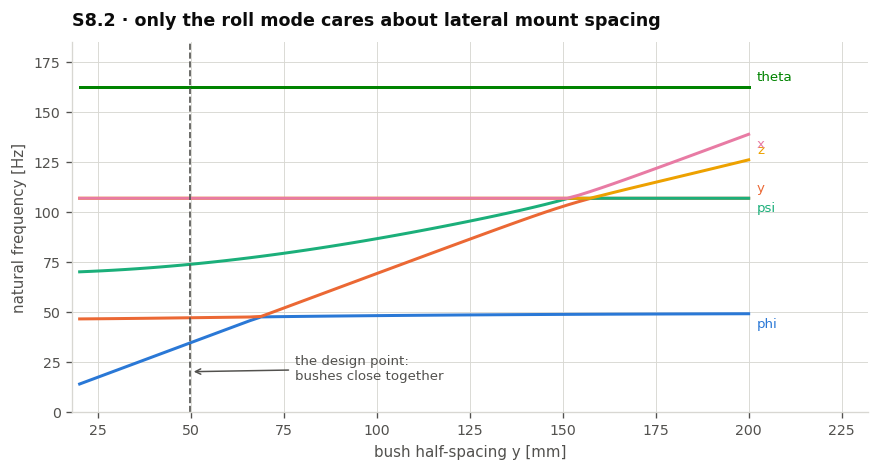

In [13]:
# How the roll mode responds to lateral spacing, everything else held fixed.
ys = np.linspace(0.02, 0.20, 60)
tab = np.zeros((ys.size, 6))
for i, yy in enumerate(ys):
    ms = []
    Rm = om.rot_from_euler_zyx(ry=P.BUSH_TILT)
    for x, z, ka, kr in ((P.X_FRONT, P.Z_FRONT, P.K_FRONT_AXIAL, P.K_FRONT_RADIAL),
                         (P.X_REAR,  P.Z_REAR,  P.K_REAR_AXIAL,  P.K_REAR_RADIAL)):
        for sy in (+1, -1):
            ms.append(om.Mount([x, sy*yy, z], [kr, ka, kr], Rm, P.LOSS_FACTOR))
    tab[i] = om.MountSystem(P.engine_body(), ms).modal().f_hz

fig, ax = plt.subplots(figsize=(7.4, 4.0))
base = P.system().modal()
for j in range(6):
    ax.plot(ys*1000, tab[:, j], color=SERIES[j], lw=1.8)
    dy = 6 if j % 2 else -6
    ax.annotate(base.labels[j].split(" ")[0], xy=(ys[-1]*1000, tab[-1, j]),
                xytext=(5, dy), textcoords="offset points",
                color=SERIES[j], fontsize=8, va="center")
ax.axvline(P.Y_HALF*1000, color=INK2, ls="--", lw=1.0)
ax.annotate("the design point:\nbushes close together",
            xy=(P.Y_HALF*1000, 20), xytext=(78, 16),
            color=INK2, fontsize=8,
            arrowprops=dict(arrowstyle="->", color=INK2, lw=0.9))
ax.set_xlim(18, 232); ax.set_ylim(0, 185)
tidy(ax, "S8.2 · only the roll mode cares about lateral mount spacing",
     "bush half-spacing y [mm]", "natural frequency [Hz]")
plt.tight_layout(); plt.show()

### S8.3 · The payoff — the paper's Fig. 8, rebuilt

Now drive the fitted 6-DOF model with the real primary couple and look at the
rotational response. The paper's Fig. 8 shows roll, pitch and yaw: one resonance
at 35 Hz, and nothing else, despite five other modes sitting between 47 and 166
Hz.

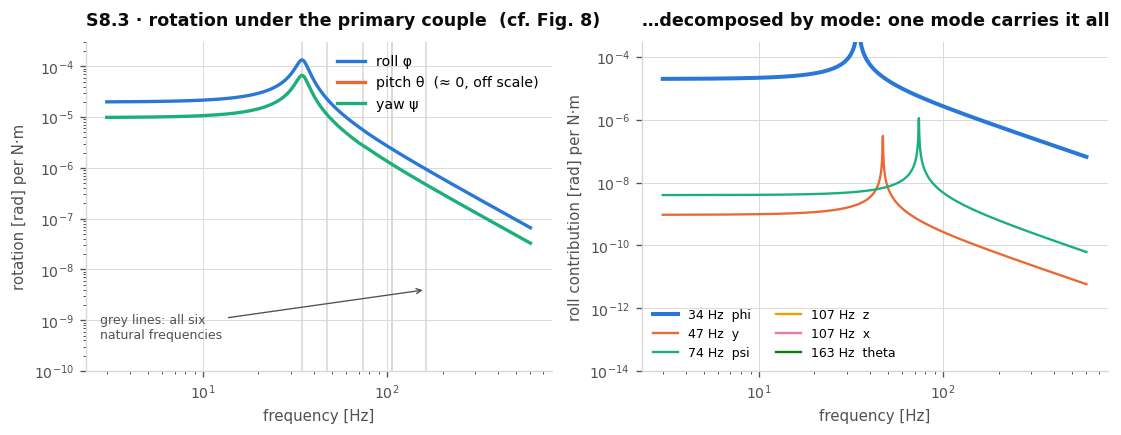

normalised participation of each mode in the primary couple:
     34.5 Hz  phi (roll)      0.999194  ████████████████████████████████████████
     47.0 Hz  y (lateral)     0.003506  
     73.8 Hz  psi (yaw)       0.003686  
    106.8 Hz  z (bounce)      0.000000  
    106.8 Hz  x (fore/aft)    0.000000  
    162.6 Hz  theta (pitch)   0.000000  


In [14]:
f_hz = np.logspace(np.log10(3), np.log10(600), 1400)
w_s  = 2*np.pi*f_hz

v = eng.excitation_vector(600.0, order=1)
v_dir = v / np.linalg.norm(v)
exc = np.zeros(6); exc[3:] = v_dir[3:]          # unit primary couple

Q = sysm.response(w_s, exc, damped=True)

fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.7))
ax = axes[0]
for j, (name, col) in enumerate((("roll φ", SERIES[0]), ("pitch θ  (≈ 0, off scale)", SERIES[1]),
                                 ("yaw ψ", SERIES[2]))):
    ax.loglog(f_hz, np.abs(Q[:, 3+j]), color=col, label=name)
for fr in res.f_hz:
    ax.axvline(fr, color=GRID, lw=0.9, zorder=0)
ax.set_ylim(1e-10, 3e-4)
tidy(ax, "S8.3 · rotation under the primary couple  (cf. Fig. 8)",
     "frequency [Hz]", "rotation [rad] per N·m")
ax.annotate("grey lines: all six\nnatural frequencies",
            xy=(res.f_hz[-1], 4e-9), xytext=(0.03, 0.10), textcoords="axes fraction",
            fontsize=7.5, color=INK2,
            arrowprops=dict(arrowstyle="->", color=INK2, lw=0.8))
ax.legend(loc="upper right")

# right: each mode's own share of the roll response
ax = axes[1]
contrib = sysm.modal_response(w_s, exc)          # (w, 6, n_modes)
for r in range(6):
    lw = 2.4 if r == int(np.argmax(res.normalised_participation(exc))) else 1.4
    ax.loglog(f_hz, np.abs(contrib[:, 3, r]) + 1e-30, color=SERIES[r], lw=lw,
              label=f"{res.f_hz[r]:.0f} Hz  {res.labels[r].split(' ')[0]}")
ax.set_ylim(1e-14, 3e-4)
tidy(ax, "…decomposed by mode: one mode carries it all",
     "frequency [Hz]", "roll contribution [rad] per N·m")
ax.legend(loc="lower left", ncol=2, fontsize=7.5)
plt.tight_layout(); plt.show()

part = res.normalised_participation(exc)
print("normalised participation of each mode in the primary couple:")
for fr, lab, pp in sorted(zip(res.f_hz, res.labels, part)):
    bar = "█" * int(round(40*pp))
    print(f"  {fr:7.1f} Hz  {lab:<14s} {pp:9.6f}  {bar}")

### S8.4 · What the rider feels: transmitted force vs engine speed

The engine's own motion is not the deliverable — the force reaching the chassis
is. Because inertia excitation grows as $\omega^2$ while transmissibility falls
as $1/\omega^2$ above resonance, the transmitted force *plateaus* above the
resonance instead of growing. That is the real prize, and it is why the paper's
Fig. 14 shows improvement everywhere except right at the 35 Hz resonance
(≈ 2100 rpm for a once-per-rev excitation).

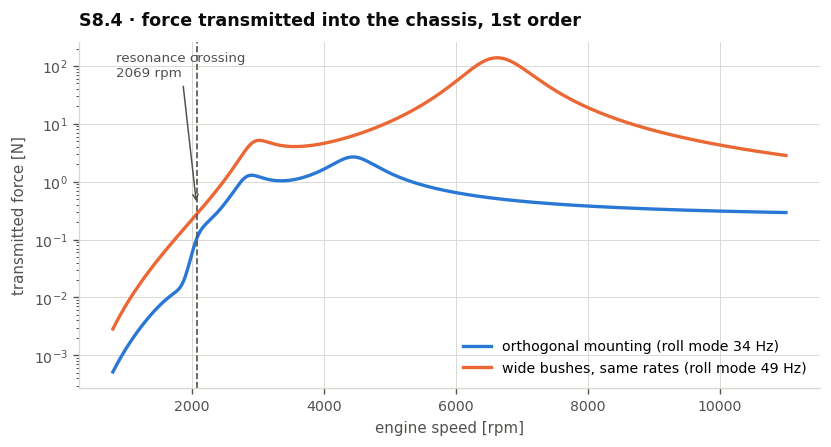

Mean reduction above 3500 rpm: 97%
Below the resonance crossing the orthogonal system is WORSE — which is
exactly what the paper's Fig. 14 reports near 2000 rpm.


In [15]:
rpm  = np.linspace(800, 11000, 500)
w_e  = rpm*2*np.pi/60

# excitation grows with rpm^2, direction fixed
M0 = np.linalg.norm(eng.harmonics(600.0, 1)[1][3:]) / 600.0**2
F_of_rpm = np.zeros((rpm.size, 6))
F_of_rpm[:, 3:] = (M0 * w_e**2)[:, None] * v_dir[3:][None, :]

Ft_ortho = sysm.transmitted_force(w_e, F_of_rpm, damped=True)

# a "conventional" comparison: same bushes, but laterally wide (rigid roll)
wide = []
Rm = om.rot_from_euler_zyx(ry=P.BUSH_TILT)
for x, z, ka, kr in ((P.X_FRONT, P.Z_FRONT, P.K_FRONT_AXIAL, P.K_FRONT_RADIAL),
                     (P.X_REAR,  P.Z_REAR,  P.K_REAR_AXIAL,  P.K_REAR_RADIAL)):
    for sy in (+1, -1):
        wide.append(om.Mount([x, sy*0.16, z], [kr, ka, kr], Rm, P.LOSS_FACTOR))
sys_conv = om.MountSystem(P.engine_body(), wide)
Ft_conv  = sys_conv.transmitted_force(w_e, F_of_rpm, damped=True)

fig, ax = plt.subplots(figsize=(7.0, 3.8))
ax.semilogy(rpm, np.linalg.norm(Ft_ortho, axis=1), color=SERIES[0],
            label=f"orthogonal mounting (roll mode {res.f_hz.min():.0f} Hz)")
ax.semilogy(rpm, np.linalg.norm(Ft_conv, axis=1), color=SERIES[1],
            label=f"wide bushes, same rates (roll mode "
                  f"{sys_conv.modal().f_hz.min():.0f} Hz)")
f1 = res.f_hz.min()
ax.axvline(f1*60, color=INK2, ls="--", lw=1.0)
ax.annotate(f"resonance crossing\n{f1*60:.0f} rpm",
            xy=(f1*60, 0.4), xytext=(0.05, 0.90), textcoords="axes fraction",
            fontsize=8, color=INK2,
            arrowprops=dict(arrowstyle="->", color=INK2, lw=0.9))
tidy(ax, "S8.4 · force transmitted into the chassis, 1st order",
     "engine speed [rpm]", "transmitted force [N]")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

k = rpm > 3500
print(f"Mean reduction above 3500 rpm: "
      f"{100*(1 - np.mean(np.linalg.norm(Ft_ortho,axis=1)[k])/np.mean(np.linalg.norm(Ft_conv,axis=1)[k])):.0f}%")
print("Below the resonance crossing the orthogonal system is WORSE — which is")
print("exactly what the paper's Fig. 14 reports near 2000 rpm.")

---
## S9 · How fragile is it? ⟨beyond the paper⟩

The paper presents the orthogonality as exact. In production, $\alpha$ moves
when you change a crankcase casting, and rubber rates drift ±20% with
temperature, age and batch. So: how much does the second mode wake up?

This is the question the paper does not ask, and the one your programme manager
will.

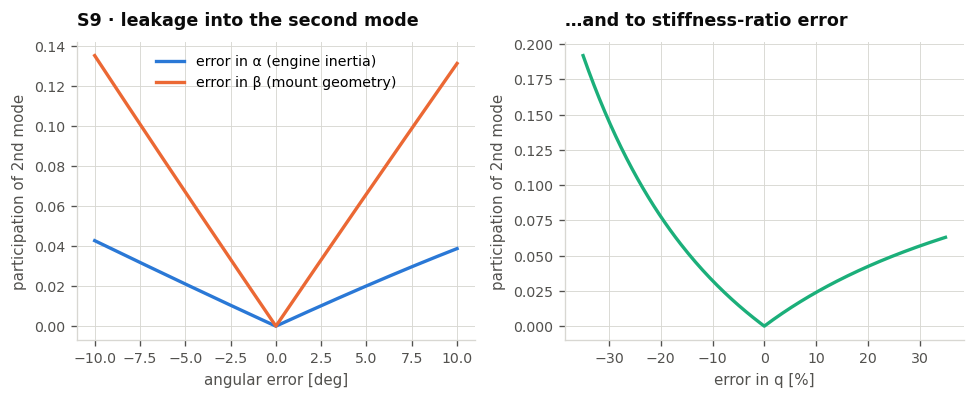

  α off by 1°  ->  2nd mode participation 0.0041
  α off by 2°  ->  2nd mode participation 0.0082
  α off by 5°  ->  2nd mode participation 0.0201
  q off by 10%  ->  2nd mode participation 0.0239
  q off by 20%  ->  2nd mode participation 0.0423
  q off by 30%  ->  2nd mode participation 0.0568


In [16]:
def leak(dalpha=0.0, dq=0.0, dbeta=0.0):
    '''Second-largest modal participation after perturbing the design.'''
    a  = alpha + dalpha
    qq = q * (1 + dq)
    b  = beta_ok + dbeta
    Mi, Ki = om.paper_system(P.MASS, I_xi, I_eta, I_zeta, a,
                             K_xi, K_eta, K_xi/qq, b, K_trans=(1.8e7, 3.5e6, 1.7e7))
    r = om.modal_from_matrices(Mi, Ki)
    pp = np.sort(r.normalised_participation(f_roll))[::-1]
    return pp[1]

d_ang = D(np.linspace(-10, 10, 201))
d_rel = np.linspace(-0.35, 0.35, 201)

fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.4))
axes[0].plot(Dg(d_ang), [leak(dalpha=x) for x in d_ang], color=SERIES[0],
             label="error in α (engine inertia)")
axes[0].plot(Dg(d_ang), [leak(dbeta=x) for x in d_ang], color=SERIES[1],
             label="error in β (mount geometry)")
tidy(axes[0], "S9 · leakage into the second mode", "angular error [deg]",
     "participation of 2nd mode")
axes[0].legend()

axes[1].plot(100*d_rel, [leak(dq=x) for x in d_rel], color=SERIES[2])
tidy(axes[1], "…and to stiffness-ratio error", "error in q [%]",
     "participation of 2nd mode")
plt.tight_layout(); plt.show()

for e in (1, 2, 5):
    print(f"  α off by {e}°  ->  2nd mode participation {leak(dalpha=D(e)):.4f}")
for e in (0.1, 0.2, 0.3):
    print(f"  q off by {100*e:.0f}%  ->  2nd mode participation {leak(dq=e):.4f}")

The leakage is *linear* in the error and gentle — a 5° error in $\alpha$ still
leaves the second mode absorbing only a few percent of the excitation. The trick
is robust, which is presumably why it survived into production. Note the
asymmetry between the two panels: the design is markedly more tolerant of
stiffness-ratio scatter than of an angular error, so tolerance the *geometry*
tightly and let the rubber rates float.

---
## S10 · Your engine

Everything above runs off two objects: a `RigidBody` and a list of `Mount`s.
Replace the numbers below with your machine's and re-run.

**What you need to measure or extract from CAD:**

| quantity | where it comes from |
|---|---|
| engine mass, full inertia tensor about the CG | CAD, or a pendulum/trifilar test as the paper did |
| mount positions relative to the CG | CAD |
| mount rates in three directions, and the bush axis | supplier data, or a rate rig |
| crank phasing, recip mass, crank radius, rod length, cylinder tilt & spacing | engine drawing |

The first thing to look at is the **feasibility check** — for many engines
$|R|$ is small enough that almost any anisotropic mount set can satisfy Eq. (22),
and for some it is not achievable at all.

In [17]:
# ---------------------------------------------------------------------------
#  EDIT THIS BLOCK
# ---------------------------------------------------------------------------
MY = dict(
    mass       = 40.0,                       # kg
    inertia    = None,                       # 3x3 tensor about CG; or use principal form below
    I_xi       = 0.95, I_eta = 1.30, I_zeta = 1.60,   # kg m^2
    alpha      = D(30.0),                    # inclination of the ξ axis
    # crank
    crank_phases = (0.0, np.pi),
    m_recip    = 0.20, m_rot = 0.0,
    stroke     = 0.054, rod_length = 0.100,
    cyl_tilt   = D(24.0), cyl_spacing = 0.070,
    balance_factor = 0.0,
    # target
    f1_target  = 35.0,                       # Hz, where you want the single mode
)

body = (om.RigidBody(MY["mass"], MY["inertia"]) if MY["inertia"] is not None
        else om.RigidBody.from_principal(MY["mass"], MY["I_xi"], MY["I_eta"],
                                         MY["I_zeta"], MY["alpha"]))

my_engine = om.Engine(
    cylinders=[om.Cylinder(ph, sy*MY["cyl_spacing"]/2, MY["cyl_tilt"],
                           MY["m_recip"], MY["m_rot"])
               for ph, sy in zip(MY["crank_phases"],
                                 np.linspace(1, -1, len(MY["crank_phases"])))],
    crank_radius=MY["stroke"]/2, rod_length=MY["rod_length"],
    balance_factor=MY["balance_factor"])

# --- 1. what does the engine actually shake with? --------------------------
h = my_engine.harmonics(600.0, n_harm=3)
print("excitation at 5730 rpm, by order:")
for k, hv in h.items():
    print(f"  order {k}:  |F| = {np.linalg.norm(hv[:3]):9.1f} N   "
          f"|M| = {np.linalg.norm(hv[3:]):9.2f} N·m")

# --- 2. feasibility --------------------------------------------------------
I_xi_, I_zeta_, alpha_ = body.principal_inplane
p_ = I_xi_/I_zeta_
R_ = om.R_from_inertia(p_, alpha_)
print(f"\np = {p_:.4f}, alpha = {Dg(alpha_):.2f} deg  ->  R = {R_:+.4f}")
print(f"minimum mount anisotropy needed:  q >= {om.q_min_for_R(R_):.2f}")

# --- 3. design -------------------------------------------------------------
for q_try in (1.5, 2.0, 3.0, 5.0):
    try:
        dd = design(I_xi_, I_zeta_, alpha_, q_try, MY["f1_target"])
        print(f"  q = {q_try:4.1f}  ->  beta = {Dg(dd['beta']):+6.2f} deg, "
              f"K_xi = {dd['K_xi']:>10,.0f} N·m/rad, delta = {Dg(dd['delta']):+6.2f} deg")
    except ValueError as e:
        print(f"  q = {q_try:4.1f}  ->  {e}")

excitation at 5730 rpm, by order:
  order 1:  |F| =       0.0 N   |M| =    136.08 N·m
  order 2:  |F| =    1049.8 N   |M| =      0.00 N·m
  order 3:  |F| =       0.0 N   |M| =      0.00 N·m

p = 0.5938, alpha = 30.00 deg  ->  R = -0.1958
minimum mount anisotropy needed:  q >= 1.48
  q =  1.5  ->  beta = -31.41 deg, K_xi =     58,080 N·m/rad, delta = +11.08 deg
  q =  2.0  ->  beta = -12.06 deg, K_xi =     53,369 N·m/rad, delta = +11.08 deg
  q =  3.0  ->  beta =  -5.76 deg, K_xi =     52,167 N·m/rad, delta = +11.08 deg
  q =  5.0  ->  beta =  -2.84 deg, K_xi =     51,638 N·m/rad, delta = +11.08 deg


### Realising it with actual bushes ⟨beyond the paper⟩

The last step — turning $(q,\beta,K^\phi_\xi)$ into mount positions and rates —
is a small inverse problem. The helper below is exactly what produced the
reconstructed RZ250 layout in `params_rz250.py`: it fits mount coordinates and
rates so that the six natural frequencies hit targets, the elastic centre lands
on the CG, and the excitation stays orthogonal to five modes.

Give it *your* frequency targets and it will do the same for your engine.

In [18]:
from scipy.optimize import least_squares

def synthesise(body, targets, exc6, n_restarts=25, seed=0):
    '''Fit a 4-bush layout to frequency targets + orthogonality.

    targets : dict of {mode label: frequency [Hz]}, labels as in om.DOF_LABELS
    exc6    : the 6-component excitation direction to be orthogonalised against
    '''
    def build(par):
        xf, xr, zf, zr, ym, kfa, kfr, kra, krr, gam = par
        Rm = om.rot_from_euler_zyx(ry=gam)
        ms = []
        for x, z, ka, kr in ((xf, zf, kfa, kfr), (xr, zr, kra, krr)):
            for sy in (+1, -1):
                ms.append(om.Mount([x, sy*ym, z], [kr, ka, kr], Rm, 0.15))
        return om.MountSystem(body, ms)

    def resid(par):
        s = build(par); r = s.modal(); out = []
        used = set()
        for lab, fq in targets.items():
            idx = [i for i, l in enumerate(r.labels) if l == lab and i not in used]
            if not idx:
                out.append(10.0); continue
            used.add(idx[0]); out.append((r.f_hz[idx[0]] - fq)/fq)
        out += list(s.elastic_centre*20.0)
        out.append(np.sort(r.normalised_participation(exc6))[::-1][1]*5.0)
        return np.array(out)

    lo = np.array([0.05, -0.45, -0.20, -0.20, 0.02, 1e5, 1e5, 1e5, 1e5, -1.2])
    hi = np.array([0.45, -0.05,  0.20,  0.20, 0.15, 5e7, 5e7, 5e7, 5e7,  1.2])
    rng = np.random.default_rng(seed); best = None
    for t in range(n_restarts):
        x0 = lo + (hi-lo)*rng.random(10)
        x0[5:9] = 10**rng.uniform(5.5, 7.4, 4)
        try:
            s = least_squares(resid, x0, bounds=(lo, hi), xtol=1e-12, ftol=1e-12,
                              max_nfev=2500)
        except Exception:
            continue
        if best is None or s.cost < best.cost:
            best = s
    return build(best.x), best

targets = {"phi (roll)": 35.0, "y (lateral)": 50.0, "psi (yaw)": 75.0,
           "z (bounce)": 105.0, "x (fore/aft)": 107.0, "theta (pitch)": 165.0}
exc6 = np.zeros(6); exc6[3:] = v_dir[3:]

sys_new, sol = synthesise(body, targets, exc6, n_restarts=25, seed=1)
rr = sys_new.modal()
print(f"fit cost {sol.cost:.3e}\n")
for m in sys_new.mounts:
    print(f"  mount at {np.round(m.position,4)} m   rates {m.stiffness/1e6} MN/m")
print("\n  achieved:", np.round(rr.f_hz, 1))
print("  targets :", np.round(list(targets.values()), 1))
print("  participation:", np.round(np.sort(rr.normalised_participation(exc6))[::-1], 5))

fit cost 8.997e-05

  mount at [ 0.2227  0.0509 -0.1124] m   rates [4.949  1.1247 4.949 ] MN/m
  mount at [ 0.2227 -0.0509 -0.1124] m   rates [4.949  1.1247 4.949 ] MN/m
  mount at [-0.2815  0.0509  0.1422] m   rates [3.923  0.8482 3.923 ] MN/m
  mount at [-0.2815 -0.0509  0.1422] m   rates [3.923  0.8482 3.923 ] MN/m

  achieved: [ 35.   50.   75.  106.  106.  164.9]
  targets : [ 35.  50.  75. 105. 107. 165.]
  participation: [0.9991 0.0001 0.0001 0.     0.     0.    ]


---
## S11 · The rest of the paper, briefly

The theory ends at Eq. (32). The remaining half of SAE 830228 is validation and
application, and it is worth knowing what is in it:

**Building Block Approach (BBA).** The engine is a matrix component (a rigid
body); the mounts are scalar components (spring + hysteretic damper). Assemble
them and you get the 6-DOF model — which is exactly what `MountSystem` does
here. They validated it with an electro-hydraulic shaker, 10–200 Hz, and got
≤7.5% error on all six frequencies (Table 2).

**Multi-DOF model.** They then dropped the "rigid chassis of infinite mass"
assumption: the chassis was modelled with 29 modes (0–500 Hz) and the mufflers
with 15 (0–1000 Hz), coupled back through BBA. Result: *the 35 Hz roll mode
barely moved*, because the chassis inertia dwarfs the engine's. That is the
justification for the simple grounded model used throughout this notebook.

A nice detail: the muffler had a 108 Hz resonance, and they killed its
transmission by putting the muffler mount **at a node of that mode** — the same
orthogonality idea applied to a different component.

**Human vibration rating (Eqs. 33–37).** Rather than quoting m/s², they scored
the result on Miwa's *vibration greatness level*, a psychophysical scale:
1/3-octave acceleration → VAL (Eq. 33) → VGL, frequency-weighted (Eq. 34) → VG,
a ratio scale like the sone (Eq. 35) → summed across bands with a 0.13 weighting
for the non-dominant bands (Eq. 36) → combined across three axes by RMS
(Eq. 37). Measured at handlebar, seat and footrests.

**The verdict (Fig. 14).** Vibration reduced at all engine speeds *except* near
2000 rpm, where the 35 Hz mode is being driven at resonance and the orthogonal
system is worse than a bolt-in engine. Bigger benefit at higher speeds. That
trade — worse at one crossing, better everywhere else — is the honest summary of
what this mounting scheme buys.

---

### Three sentences to keep

1. A mode responds only to the *projection* of the excitation onto its shape, so
   a mode orthogonal to the excitation is free — it can sit anywhere in
   frequency and cost you nothing.
2. Deliberately matching elastic cross-coupling to inertial cross-coupling
   ($I_{zx}/I_z = -K_{\phi\psi}/K_{\psi\psi}$) makes one of the two roll–yaw
   modes orthogonal to a pure rolling couple.
3. You then get to be soft in exactly one direction and stiff in the other five
   — which is the whole reason the RZ250 could have rubber mounts and a chassis
   that still worked.